# Homework 02: Multi-Class Classification with Neural Networks

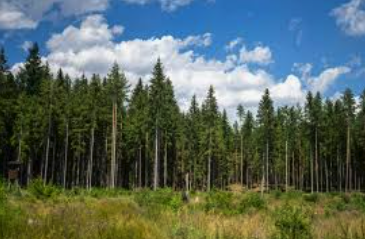

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


In [1]:
import tensorflow as tf
print(tf.__version__)

2.16.2


In [2]:
# Useful imports
import os

# (1) Set TF log level BEFORE importing tensorflow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress INFO/WARNING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers.schedules import CosineDecay

# (2) Make runs reproducible
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

# (optional but helpful) make TF ops more deterministic
# tf.config.experimental.enable_op_determinism()

# (3) FAST mode (controls epochs everywhere)
FAST = False
EPOCHS = 20

$$k\cdot\sigma$$

In [3]:
def plot_history(history):
    n_epochs = len(history.history["accuracy"])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    # ----- Loss -----
    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history["loss"], label="Train Loss", color="tab:red")
    if "val_loss" in history.history:
        plt.plot(epochs, history.history["val_loss"], label="Val Loss", color="tab:orange")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.grid(True)
    plt.legend()

    # ----- Accuracy -----
    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history["accuracy"], label="Train Acc", color="tab:blue")
    if "val_accuracy" in history.history:
        plt.plot(epochs, history.history["val_accuracy"], label="Val Acc", color="tab:green")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.title("Training vs Validation Accuracy")
    plt.grid(True)
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print(f"Final Train Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Train Acc:  {history.history['accuracy'][-1]:.4f}")
    if "val_accuracy" in history.history:
        print(f"Final Val Acc:    {history.history['val_accuracy'][-1]:.4f}")

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [4]:
# This cell intentionally does NOTHING heavy.
# Dataset preparation is done ONLY in Problem 1 Part A.

print("✅ Dataset will be prepared in Problem 1 Part A")

✅ Dataset will be prepared in Problem 1 Part A


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [5]:


random_seed = 42

# Load dataset
X, y = fetch_covtype(return_X_y=True)  # y in {1..7}

# Build balanced subset
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()

rng = np.random.default_rng(random_seed)
idx = np.concatenate([
    rng.choice(np.where(y == c)[0], size=min_count, replace=False)
    for c in classes
])
rng.shuffle(idx)

X_sub = X[idx]
y_sub = y[idx] - 1   # relabel to 0..6

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=random_seed
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔑 DEFINE THESE ONCE
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))

print("X_train shape:", X_train.shape)
print("n_features:", n_features)
print("n_classes:", n_classes)

X_train shape: (15383, 54)
n_features: 54
n_classes: 7


In [6]:
print("Classes in y_train:", np.unique(y_train))
print("n_classes:", len(np.unique(y_train)))
print("Class counts train:", Counter(y_train))

Classes in y_train: [0 1 2 3 4 5 6]
n_classes: 7
Class counts train: Counter({5: 2198, 1: 2198, 0: 2198, 2: 2198, 6: 2197, 3: 2197, 4: 2197})


### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



In [7]:
def build_baseline_model(n_features, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    return model

Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3909 - loss: 1.8561 - val_accuracy: 0.4979 - val_loss: 1.5091
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5286 - loss: 1.3261 - val_accuracy: 0.5444 - val_loss: 1.2264
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5570 - loss: 1.1185 - val_accuracy: 0.5739 - val_loss: 1.0969
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5878 - loss: 1.0158 - val_accuracy: 0.6068 - val_loss: 1.0284
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6110 - loss: 0.9591 - val_accuracy: 0.6201 - val_loss: 0.9869
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6242 - loss: 0.9231 - val_accuracy: 0.6315 - val_loss: 0.9585
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6336 - loss: 0.8975 - val_accuracy: 0.6383 - val_loss: 0.9374
Epoch 8/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6386 - loss: 0.8780 - val_accu

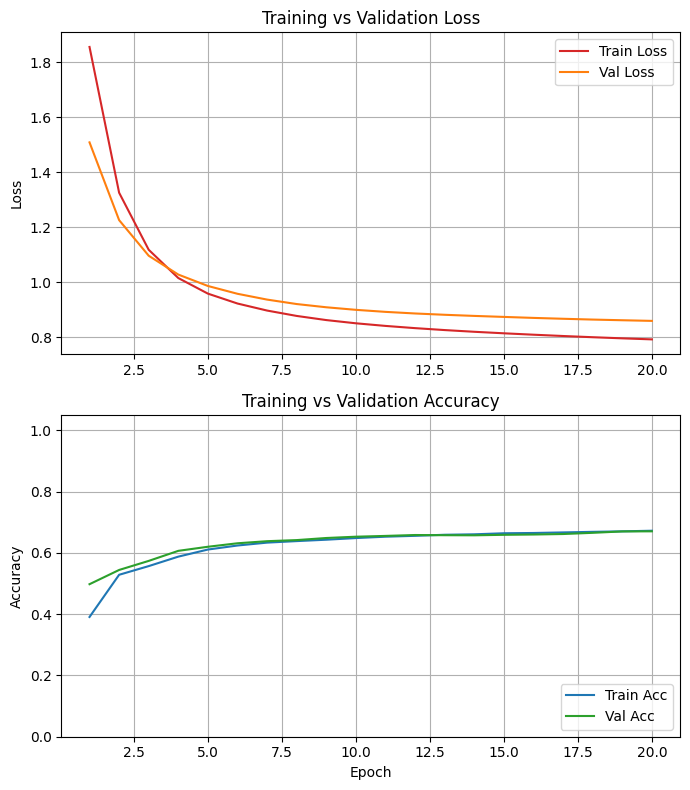

Final Train Loss: 0.7927
Final Train Acc:  0.6724
Final Val Acc:    0.6705
a1a = 0.6724


In [8]:
tf.keras.backend.clear_session()

model = build_baseline_model(n_features, n_classes)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

plot_history(history)
a1a = history.history["accuracy"][-1]   # or val_accuracy if asked
print(f"a1a = {a1a:.4f}")

In [9]:
a1a = history.history["accuracy"][-1]
print(f"a1a = {a1a:.4f}")

a1a = 0.6724


In [10]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.6724


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!

In [ ]:
batch_sizes = [4, 8, 16, 128]
histories_bs = {}
final_val_acc_by_bs = {}

for i, bs in enumerate(batch_sizes, start=1):
    tf.keras.backend.clear_session()

    model = build_baseline_model(n_features, n_classes)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\n[Problem 2] ({i}/{len(batch_sizes)}) Training with batch_size = {bs}")

    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=bs,
        validation_split=0.2,
        verbose=1
    )

    histories_bs[bs] = history
    final_val_acc_by_bs[bs] = history.history["val_accuracy"][-1]

# pick best batch size by final validation accuracy
a2a = max(final_val_acc_by_bs, key=final_val_acc_by_bs.get)
a2b = float(final_val_acc_by_bs[a2a])

print(f"\nBest batch size (a2a) = {a2a}")
print(f"Best val accuracy (a2b) = {a2b:.4f}")

# Plot only the best run (saves lots of time)
plot_history(histories_bs[a2a])


[Problem 2] (1/4) Training with batch_size = 4
Epoch 1/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - accuracy: 0.4794 - loss: 1.4214 - val_accuracy: 0.5986 - val_loss: 1.0693
Epoch 2/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - accuracy: 0.6066 - loss: 0.9681 - val_accuracy: 0.6380 - val_loss: 0.9583
Epoch 3/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.6306 - loss: 0.8970 - val_accuracy: 0.6558 - val_loss: 0.9250
Epoch 4/20
3075/3077 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6377 - loss: 0.8696

In [ ]:
final_acc_by_bs = {
    bs: h.history["accuracy"][-1]
    for bs, h in histories_bs.items()
}

In [ ]:
a2a = max(final_acc_by_bs, key=final_acc_by_bs.get)
a2b = final_acc_by_bs[a2a]

print("a2a =", a2a)


In [ ]:
a2a = int(a2a)         

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

In [ ]:
print("✅ DONE Problem 2")

## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.


In [ ]:
learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
histories_lr = {}

for lr in learning_rates:
    tf.keras.backend.clear_session()

    model = build_baseline_model(n_features, n_classes)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,          # use global (20 when FAST=False)
        batch_size=32,
        validation_split=0.2,   # ⭐ required
        verbose=0
    )

    histories_lr[lr] = history

    print(f"\nlearning_rate = {lr:.0e}")
    plot_history(history)

In [ ]:
final_acc_by_lr = {lr: h.history["val_accuracy"][-1] for lr, h in histories_lr.items()}
a3a = max(final_acc_by_lr, key=final_acc_by_lr.get)  # best LR
a3b = final_acc_by_lr[a3a]                           # best accuracy



In [ ]:
a3a = float(a3a)        

In [ ]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = a3a  # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

In [ ]:
# Set a3b to the accuracy found by the best learning rate

a3b = a3b # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

In [ ]:
print("✅ DONE Problem 3")

## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.

In [ ]:
from tensorflow.keras.optimizers.schedules import CosineDecay

initial_lrs = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
results_cos = []   # list of (init_lr, val_acc_at_end)

epochs = EPOCHS          # 20 when FAST=False
batch_size = 32

steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
decay_steps = steps_per_epoch * epochs

histories_cos = {}  # optional, if you still want to keep histories

for init_lr in initial_lrs:
    tf.keras.backend.clear_session()

    lr_schedule = CosineDecay(
        initial_learning_rate=init_lr,
        decay_steps=decay_steps,
        alpha=0.0
    )

    model = build_baseline_model(n_features, n_classes)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    histories_cos[init_lr] = history
    plot_history(history)

    val_acc_end = float(history.history["val_accuracy"][-1])
    results_cos.append((init_lr, val_acc_end))

best_init_lr, best_val_acc = max(results_cos, key=lambda x: x[1])

a4a = float(best_init_lr)
a4b = float(best_val_acc)

print(f"a4a = {a4a:.4f}")
print(f"a4b = {a4b:.4f}")

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

In [ ]:
print("✅ DONE Problem 4")

## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

In [ ]:
# --- Appendix: Optimized for Speed ---

# 1. Create the sample ONCE
df_sample = df.sample(frac=0.01, random_state=42)

# 2. Class distribution plot (Use df_sample)
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df_sample, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types (Sampled)")
plt.show()

# 3. Elevation distribution (Use df_sample)
# This is the line that usually crashes the kernel if not sampled!
plt.figure(figsize=(10,6))
sns.histplot(data=df_sample, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type (Sampled)")
plt.show()

# 4. Correlation heatmap (Use df_sample)
plt.figure(figsize=(10,8))
corr = df_sample[quant_features].corr() # Correlation on 500k rows is slow!
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Sampled)")
plt.show()

# 5. Mean elevation (This one is actually okay on full df, but let's use sample to be safe)
df_sample.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type (Sampled)")
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from collections import Counter

random_seed = 42

# Load dataset
X, y = fetch_covtype(return_X_y=True)  # y in {1..7}

# Balanced subset
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()

rng = np.random.default_rng(random_seed)
idx = np.concatenate([
    rng.choice(np.where(y == c)[0], size=min_count, replace=False)
    for c in classes
])
rng.shuffle(idx)

X_sub = X[idx]
y_sub = y[idx] - 1  # 0..6

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=random_seed
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Required globals
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))

print("✅ Ready:", X_train.shape, X_test.shape, "n_features:", n_features, "n_classes:", n_classes)
print("Train counts:", Counter(y_train))

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers.schedules import CosineDecay

# --- safety check ---
missing = [v for v in ["X_train","y_train","X_test","y_test","n_features","n_classes","a2a","a3a","a4a"] if v not in globals()]
if missing:
    raise NameError(f"Missing {missing}. Run Problems 1–4 first.")

EPOCHS = 20

best_batch  = int(a2a)     # from Problem 2
best_lr     = float(a3a)   # from Problem 3
best_initlr = float(a4a)   # from Problem 4

def build_model(n_features, n_classes):
    return keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(n_classes, activation="softmax"),
    ])

steps_per_epoch = int(np.ceil(len(X_train) / best_batch))
total_steps = EPOCHS * steps_per_epoch

results = {}

# ---- Candidate A: constant LR ----
tf.keras.backend.clear_session()
model_const = build_model(n_features, n_classes)
model_const.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
hist_const = model_const.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=best_batch,
    validation_split=0.2,
    verbose=0
)
results["constant"] = (model_const, hist_const)

# ---- Candidate B: cosine decay ----
tf.keras.backend.clear_session()
lr_schedule = CosineDecay(
    initial_learning_rate=best_initlr,
    decay_steps=total_steps,
    alpha=0.0
)
model_cos = build_model(n_features, n_classes)
model_cos.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
hist_cos = model_cos.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=best_batch,
    validation_split=0.2,
    verbose=0
)
results["cosine"] = (model_cos, hist_cos)

# ---- Choose best by final validation accuracy ----
final_val_acc = {k: h.history["val_accuracy"][-1] for k, (_, h) in results.items()}
best_key = max(final_val_acc, key=final_val_acc.get)

best_model, best_history = results[best_key]
print("Best choice:", best_key)
plot_history(best_history)

# a5a = best training accuracy
a5a = float(best_history.history["accuracy"][-1])

# a5b = test accuracy
_, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
a5b = float(test_acc)

In [ ]:
# Set a5a to the best training accuracy found by your best model

a5a = best_history.history["accuracy"][-1]            # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

In [ ]:
# Set a5b to the test accuracy found by your best model

a5b = test_acc             # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

In [ ]:
print("✅ DONE Problem 5")

## Reflection Questions (ungraded)

1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

3. **More epochs, same LR.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc? 

4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


In [ ]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()
